# Quick start tutorial of how to use the SUIT toolbox for fMRI analysis
In this tutorial, you will learn how to use SUITPy, the Python implementation of the SUIT cerebellar toolbox, to perform a complete cerebellar fMRI analysis. We will walk through the essential steps:
* Isolating the cerebellum
* Normalizing volumes into SUIT space
* Reslicing contrast maps
* Generating visualizations within each step.

*You can find additional details and explanations for each step in the corresponding sections of the documentation.*


## Isolate the cerebellum


This example shows how to use ``isolate`` to create a cerebellum–brainstem mask from a T1w or T2w anatomical image. The mask is required for normalization and helps avoid signal spillover from nearby cortex.

In [ ]:
# Import necessary packages
from nilearn import plotting
import SUITPy as suit
import nibabel as nib

In [ ]:
# This function generates isolation mask for the cerebellum based on a T1 scan
ants_image = suit.isolate('sub-ex_T1w.nii.gz')

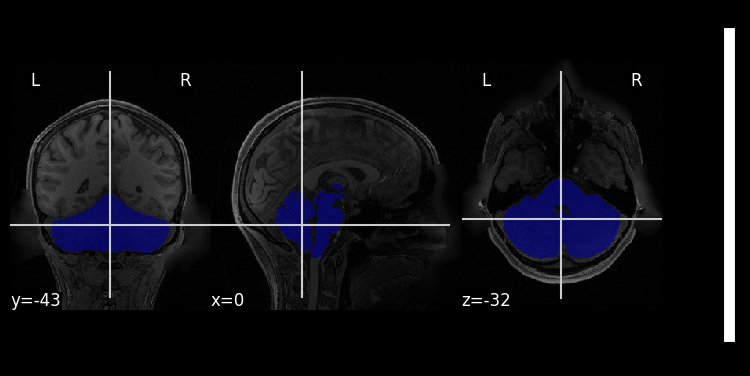

In [ ]:
# Visualize the results:
img = nib.load('sub-ex_T1w.nii.gz')
mask = nib.load('sub-ex_T1w_cerebellum_dseg.nii.gz')
plotting.plot_roi(mask,img)

## Normalize the cerebellum to the SUIT template
The SUIT normalization module estimates a deformation field that aligns an individual’s cerebellum to the SUIT template, using the isolation mask from the previous step. In SUITPy, this procedure is implemented with ANTsPy (available from version 2.1). The resulting deformation can then be applied to reslice anatomical or functional data into SUIT space.

In the simplest usage, normalize requires only the subject’s T1-weighted image and the isolation mask.

In [ ]:
# Import necessary packages
from nilearn import plotting
import SUITPy.normalize as normalize
import nibabel as nib

In [ ]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum mask.
mytx = normalize(source_file = 'anatomical_sess-01.nii',
                 mask_file = 'anatomical_sess-01_cerebellum_dseg.nii.gz')

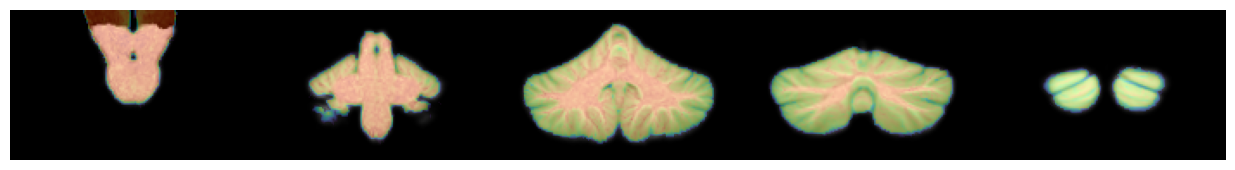

In [ ]:
import ants
w_anat_img = mytx['warpedmovout']
template_img = ants.image_read('/templates//tpl-SUIT_T1w.nii.gz')
ants.plot(template_img, overlay=w_anat_img, axis=1, nslices=5, overlay_alpha=0.4)

## Reslice functional data in SUIT space
This example shows the use of the function reslice_image. We assume you have produced an isolation mask and a deformation file (y_suitdef.nii) using the Matlab version (for detail information please refer to reslicing documentation).

In [ ]:
# Import necessary packages
from nilearn import plotting
import SUITPy.reslice as reslice
import nibabel as nib

In [ ]:
output_img = reslice.reslice_image(source_image = 'anatomical_sess-01.nii',
                                    deformation = 'y_suitdef.nii',
                                    mask = 'c_anatomical_sess-01_pcereb.nii')

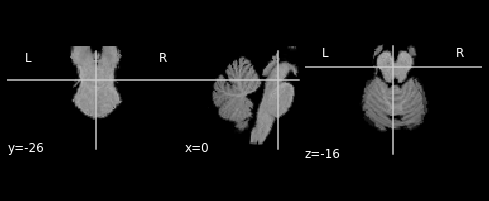

In [ ]:
plotting.plot_anat(output_img)

## Conduct group-analysis in SUIT space
Once individual subjects have been isolated and normalized to SUIT space, group-level analyses can be carried out using any statistical framework (e.g., **FSL, SPM, .etc**). SUITPy’s role is to ensure that all cerebellar data are aligned to a common high-resolution template, so the group analysis itself is not restricted to a specific package.

In practice, group analysis in SUIT space typically involves:

* Normalizing each subject’s functional or statistical map (e.g., contrast estimate, t-map, beta map) into SUIT space using SUITPy’s normalization pipeline.

* Reslicing all subjects’ data to the same SUIT template grid using suit_reslice.

* Stacking the normalized volumes across subjects into a single subject list.

* Applying your preferred group-level model, such as:

  * one-sample / paired / independent-samples t-tests

  * GLMs with covariates (age, behavior, performance, etc.)

  * mixed-effects models for multi-session datasets

* Correcting for multiple comparisons (FDR, cluster-based correction, threshold-free cluster enhancement, etc.).

* Visualising the group results on the SUIT flatmap using suit_flatmap.plot_map.

SUITPy standardizes the cerebellar space and provides high-quality flatmaps; the statistical analysis itself can be performed with whichever neuroimaging or statistical tools best fit your pipeline.